<a href="https://colab.research.google.com/github/tisuama/LLM-Learning/blob/main/HW7_LLM_FT%2BRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Wed Mar 25 09:02:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   72C    P0             22W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Sample Code Structure Guide

The sample code is organized into the structure:
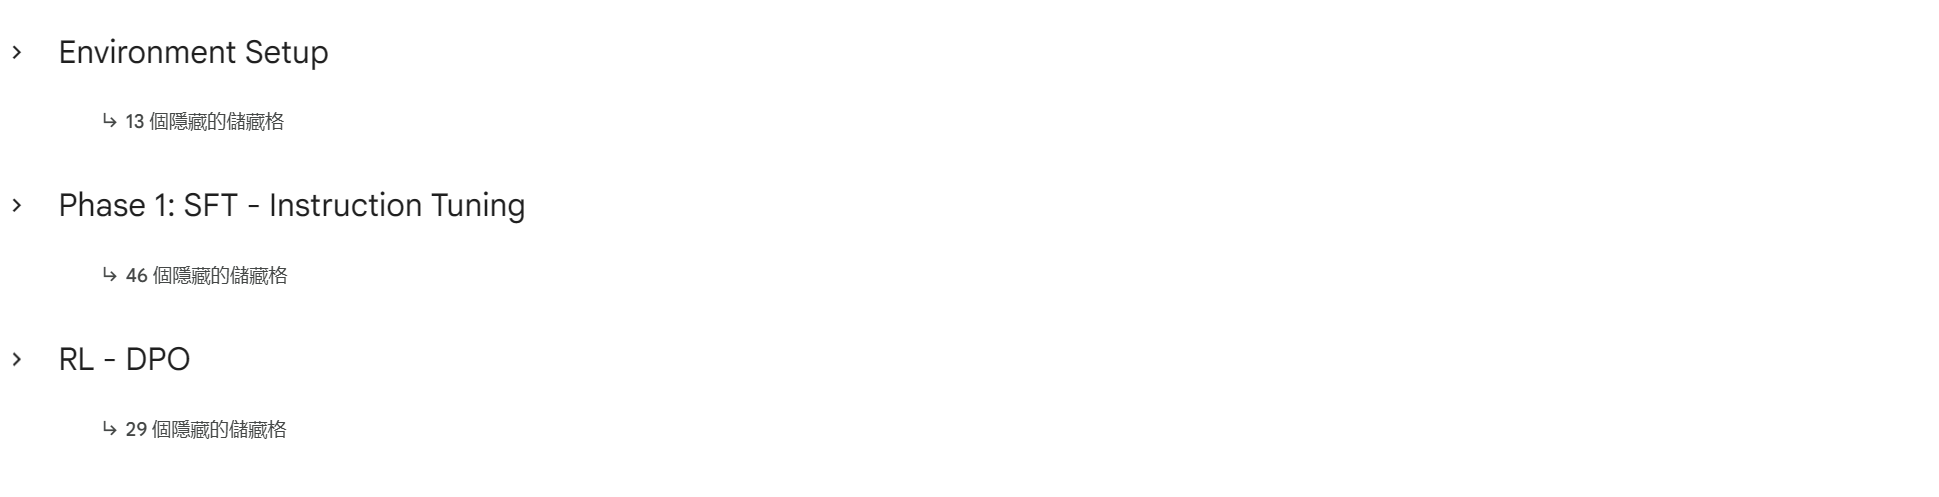

- Environment Setup
    - Set up essential environment settings such as package installation, utility function definition, global package import (packages that are used by both SFT and RL).
    - You **SHOULD RUN** this section **WHENEVER** you start / restart a Colab session.
- SFT
    - The section of the HW7 SFT phase.
    - Expand the tab and run the code cells in it if you are going to do the SFT phase.
- RL
    - The section of the HW7 RL phase.
    - Expand the tab and run the code cells in it if you want to do the RL phase.

## Environment Setup

In [2]:
from google.colab import drive
# drive.mount('/content/drive')

### Package Installation (~ 5 mins)

In [3]:
# 1. 卸载冲突包
!pip uninstall torch torchvision torchaudio bitsandbytes -y

# 2. 安装稳定的 CUDA 12.6 版本 PyTorch
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

# 3. 重新安装 bitsandbytes
!pip install bitsandbytes --no-cache-dir
%pip install  --upgrade "transformers[torch]==4.57.1"
%pip install  --upgrade accelerate datasets
%pip install  --upgrade trl[peft]
%pip install  loralib huggingface_hub
%pip install  gradio

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download.pytorch.org/whl/cu126/torch-2.11.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cu126/torchvision-0.26.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached https://download-r2.pytorch.org/whl/cu126/torchaudio-2.11.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
Using cached https://download.pytorch.org/whl/cu126/torch-2.11.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl (830.5 MB)
Using cached https://download-r2.pytorch.org/whl/cu126/torchvision-0.26.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl (7.3 MB)
Using cached https://download-r2.pytorch.org/whl/cu126/torchaudio-2.11.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 353.2 MB/s eta 0:00:00


In [ ]:
!python -m bitsandbytes

=================== bitsandbytes v0.49.2 ===================
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
  libc: glibc-2.35
Python: 3.12.13
PyTorch: 2.11.0+cu126
  CUDA: 12.6
  HIP: N/A
  XPU: N/A
Related packages:
  accelerate: 1.13.0
  diffusers: 0.37.0
  numpy: 2.0.2
  pip: 24.1.2
  peft: 0.18.1
  safetensors: 0.7.0
  transformers: 4.57.1
  triton: 3.6.0
  trl: 0.29.1
PyTorch settings found: CUDA_VERSION=126, Highest Compute Capability: (8, 9).
Checking that the library is importable and CUDA is callable...
SUCCESS!


### Package Import (~ 30 secs)

In [ ]:
import os
import sys
import torch
import random
import numpy as np
import pandas as pd

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import prepare_model_for_kbit_training, PeftModel

### Reproducibility Setting

#### **Why Set the Seed and Ensure Deterministic Behavior?**

TL;DR: TAs can get the same result in our machine as yours.

In machine learning, especially when training models, randomness is often involved in various aspects, such as:

*   **Weight Initialization:** The initial values of a model's weights are often randomly assigned.
*   **Data Shuffling:** Datasets are typically shuffled before training to ensure the model doesn't learn the order of the data.
*   **Dropout:** A regularization technique that randomly deactivates a percentage of neurons during training.
*   **GPU Operations:** Some operations on GPUs can be non-deterministic due to how parallel computations are handled.

**Setting the seed** for random number generators (like those in Python's `random`, NumPy, and PyTorch) ensures that the sequence of random numbers generated is the same every time you run your code.

**Ensuring deterministic behavior** for operations (especially on GPUs) guarantees that the same inputs will always produce the same outputs.

**Why is this important?**

*   **Reproducibility:** This is the most crucial reason. By setting the seed and ensuring deterministic operations, you can reproduce your experimental results exactly. This is essential for debugging, comparing different models or hyperparameter settings, and for others to verify your work.
*   **Debugging:** If your model is not performing as expected, being able to reproduce the exact same training run helps you isolate the source of the issue.
*   **Comparison:** When comparing the performance of different models or techniques, you want to be sure that any observed differences are due to the changes you made, not random chance.

In summary, setting the seed and aiming for deterministic operations are best practices in machine learning to ensure your experiments are reproducible and reliable.

In [ ]:
# Ensure reproducibility in training in pytorch and hf transformers
def set_seed(seed: int = 42):
    """Sets the seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

### Huggingface Token Setup (TODO)



**Why you need an HF token:**

Accessing models and datasets on the Hugging Face Hub often requires authentication, especially for private resources. Your Hugging Face token serves as your credential.

**How Colab Secret Keys work:**

Colab's secret manager provides a secure way to store sensitive information like your HF token. Instead of embedding the token directly in your code (which is a security risk), you store it as a secret in Colab. Your notebook can then access this secret without displaying the token value itself, preventing accidental exposure if you share your notebook.

**How to get a HF token?**

Ref: [GenAI 2025 HW1 Slide](https://speech.ee.ntu.edu.tw/~hylee/GenAI-ML/2025-fall-course-data/hw1.pdf)

In [ ]:
from huggingface_hub import login
from google.colab import userdata

# Saving your token as a secret key in Colab is recommended for safety
hf_token = userdata.get('HF')
# While it's strongly unrecommended, you can also type in your token for convenience
#hf_token = "<replace_with_your_token>"

login(token=hf_token)

### Helper Functions

Some useful utility functions. You SHOULD NOT MODIFY this section.

In [ ]:
def add_generation_prompt(tokenizer):
    generation_chat_template = """{{ bos_token }}
{%- if messages[0]['role'] == 'system' -%}
    {%- if messages[0]['content'] is string -%}
        {%- set first_user_prefix = messages[0]['content'] + '\n\n' -%}
    {%- else -%}
        {%- set first_user_prefix = messages[0]['content'][0]['text'] + '\n\n' -%}
    {%- endif -%}
    {%- set loop_messages = messages[1:] -%}
{%- else -%}
    {%- set first_user_prefix = "" -%}
    {%- set loop_messages = messages -%}
{%- endif -%}
{%- for message in loop_messages -%}
    {%- if (message['role'] == 'user') != (loop.index0 % 2 == 0) -%}
        {{ raise_exception("Conversation roles must alternate user/assistant/user/assistant/...") }}
    {%- endif -%}
    {%- if (message['role'] == 'assistant') -%}
        {%- set role = "model" -%}
    {%- else -%}
        {%- set role = message['role'] -%}
    {%- endif -%}
    {{ '<start_of_turn>' + role + '\n' + (first_user_prefix if loop.first else "") }}
    {%- if message['role'] == 'assistant' -%}
        {% generation %}
        {%- if message['content'] is string -%}
            {{ message['content'] | trim }}
        {%- elif message['content'] is iterable -%}
            {%- for item in message['content'] -%}
                {%- if item['type'] == 'image' -%}
                    {{ '<start_of_image>' }}
                {%- elif item['type'] == 'text' -%}
                    {{ item['text'] | trim }}
                {%- endif -%}
            {%- endfor -%}
        {%- else -%}
            {{ raise_exception("Invalid content type") }}
        {%- endif -%}
        {{ '<end_of_turn>\n' }}
        {% endgeneration %}
    {%- else -%}
        {%- if message['content'] is string -%}
            {{ message['content'] | trim }}
        {%- elif message['content'] is iterable -%}
            {%- for item in message['content'] -%}
                {%- if item['type'] == 'image' -%}
                    {{ '<start_of_image>' }}
                {%- elif item['type'] == 'text' -%}
                    {{ item['text'] | trim }}
                {%- endif -%}
            {%- endfor -%}
        {%- else -%}
            {{ raise_exception("Invalid content type") }}
        {%- endif -%}
        {{ '<end_of_turn>\n' }}
    {%- endif -%}
{%- endfor -%}
{%- if add_generation_prompt -%}
    {{'<start_of_turn>model
'}}
{%- endif -%}"""
    tokenizer.chat_template = generation_chat_template
    return tokenizer


# Define a helper function to load and set up the model and tokenizer
def get_model_tokenizer(model_name, return_model=True, return_tokenizer=True):

    model = None
    tokenizer = None
    if return_tokenizer:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        tokenizer = add_generation_prompt(tokenizer)
    if return_model:
        # Set up the quantization config
        quant_config = BitsAndBytesConfig(
          load_in_4bit=True,
          bnb_4bit_use_double_quant=True,
          bnb_4bit_quant_type="nf4",
          bnb_4bit_compute_dtype=torch.bfloat16
        )
        # Load the model from Huggingface and apply quantization
        model = AutoModelForCausalLM.from_pretrained(
          model_name,
          quantization_config=quant_config,
          trust_remote_code=True,
          low_cpu_mem_usage=True,
        )
        model = prepare_model_for_kbit_training(model)
    if return_model and return_tokenizer:
        tokenizer.pad_token_id = 0
        tokenizer.eos_token_id = 1
        model.eos_token_id = tokenizer.eos_token_id
        model.config.eos_token_id = tokenizer.eos_token_id

    return model, tokenizer

def apply_adapter(model, adapter_name):
    result_model = PeftModel.from_pretrained(
        model,
        adapter_name,
        device_map="auto"
    )
    return result_model

### Set up Optional Variables (TODO)

Expand this tab and modify the variables to enable and set up some optional operations (save to drive, wandb, ...)

In [ ]:
SAVE_FULL_MODEL = False # Set to True if you want to save the full model

SAVE_TO_DRIVE = False # Set to True if you want to save the model to your Google Drive
# Modify CKPT_PATH to the path you want to save
CKPT_PATH = ""

# CAUTION: If both SAVE_FULL_MODEL and SAVE_TO_DRIVE is set True, ensure your Google Drive has sufficient space.
# Otherwise it is very possible that you exceed your drive space

USE_WANDB = True # Set to True if you want to use wandb

## Phase 1: SFT - Instruction Tuning

### Package Import

In [ ]:
from tqdm import tqdm
import gradio as gr
from peft import LoraConfig, get_peft_model
from datasets import load_dataset, DatasetDict, concatenate_datasets
from trl import SFTTrainer, SFTConfig

### Load the Model and Tokenizer (10 mins ~ 30 mins)

- 10 mins: default, load TA-modified gemma
- 30 mins: optional, load official gemma and apply some operation (only used when the TA's version has some issues)

**Caution**:

TL;DR
There are only 2 models you can finetune:
1. `gemma-3-4b-pt` (requires modification for SFT later)
2. `jaxon3062/gemma-3-4b-pt-chat`


You can **ONLY** finetune `gemma-3-4b-pt` in HW7. Finetuning other models are **PROHIBITTED**.
However, to save your time doing HW7,
we recommend to use `jaxon3062/gemma-3-4b-pt-chat`
(another version of `gemma-3-4b-pt` modified by TA).
Otherwise you will have to spend an additional 30 mins to modify `gemma-3-4b-pt`.

**Load `jaxon3062/gemma-3-4b-pt-chat-bnb-4bit`** (~ 10 mins)

In [35]:
base_model_name = "jaxon3062/gemma-3-4b-pt-chat"
model, tokenizer = get_model_tokenizer(base_model_name)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


**(Optional) Load `google/gemma-3-4b-pt` + Modification** (~ 30 mins)

In [ ]:
load_original_gemma = False # Set `true` if you want to load the original gemma

if load_original_gemma:
    from trl import clone_chat_template
    base_model_name = "google/gemma-3-4b-pt"
    reference_chat_template_name = "google/gemma-3-4b-it"
    model, tokenizer = get_model_tokenizer(base_model_name)
    # Set up the chat format
    model, tokenizer, added_tokens = clone_chat_template(model, tokenizer, reference_chat_template_name)
    model = prepare_model_for_kbit_training(model)

### (Optional) Chat with the Model Before SFT

You can chat with the model before SFT to observe how it behaves without instruction tuning.

In [ ]:
def chat_interface(message, history):
    # Format the chat history for the model
    prompt = ""
    SYSTEM_PROMPT = "You are a helpful assistant."
    prompt += SYSTEM_PROMPT
    for human, assistant in history:
        prompt += human
        prompt += assistant
    prompt += message

    print(f"prompt: {prompt}")
    # Get the model response
    model.eval()
    with torch.no_grad():
        inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            eos_token_id=tokenizer.convert_tokens_to_ids(["<eos>", "<end_of_turn>"])
        )
        output = tokenizer.decode(out[0], skip_special_tokens=False).strip()
        response = tokenizer.decode(out[0][len(inputs[0]):], skip_special_tokens=True).strip()

    print(f"response: {response}")
    return response

# Create the Gradio interface
iface = gr.ChatInterface(
    fn=chat_interface,
    title="Gemma 3 4b Chat",
    description="Chat with the Gemma model.",
    examples=[
        ["Where is the capital of France?"],
        ["Who is Julius Caesar?"],
    ],
)

iface.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ee36e70bcd3c6a0a33.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ee36e70bcd3c6a0a33.gradio.live


### Load and Preprocess Dataset

#### Load dataset

In [ ]:
# Load the dataset
# Using other datasets is PROHIBITED!
ds = load_dataset("jaxon3062/smoltalk-gemma3-1024", "filtered-rich")

In [ ]:
# Sort the filtered dataset by token length in descending order
NUM_PROC = 4
MAX_TOKEN_LENGTH = 512

ds_filtered = DatasetDict({
    "train": ds["train"],
    "test": ds["test"],
})


ds_filtered["train"] = ds_filtered["train"].map(
    lambda x: {
        "token_length": len(tokenizer.apply_chat_template(x["messages"], tokenize=True, add_generation_prompt=False))
    },
    num_proc=NUM_PROC
).sort("token_length", reverse=True).filter(lambda x: x["token_length"] < MAX_TOKEN_LENGTH, num_proc=NUM_PROC)
print(ds_filtered["train"][:1])
ds_filtered["test"] = ds_filtered["test"].filter(lambda x: 0 <= x["idx"] < 100, num_proc=NUM_PROC)

ds_filtered

{'messages': [[{'content': "You're an AI assistant for text re-writing. Rewrite the input text to make it more professional and formal while retaining its essential content.", 'role': 'system'}, {'content': 'I\'m thrilled to share the completion of my research project, "Voices of the Enslaved: Stories of Resistance and Resilience." This journey has been both enlightening and emotionally charged. One of the most poignant moments was discovering a diary entry from Maria Johnson, an enslaved woman from Alabama. Her words not only captured the daily struggles but also the moments of defiance and hope that kept her and her community going.\n\nThis project has deepened my understanding of the complex social and cultural transformations during the American Civil War era. It has also reinforced my commitment to ensuring that these voices, often overlooked in historical narratives, are heard and honored. The research has been published in the *Journal of Southern History* and is now being expan

DatasetDict({
    train: Dataset({
        features: ['messages', 'source', 'idx', 'token_length'],
        num_rows: 4772
    })
    test: Dataset({
        features: ['messages', 'source', 'idx'],
        num_rows: 100
    })
})

#### Subsample the dataset for training (TODO)

Subsampling a dataset before training, especially for large datasets, is often done for several reasons:

1.  **Faster Training Times:** Training on a smaller subset of data is significantly faster than training on the entire dataset. This allows for quicker experimentation and iteration.
2.  **Resource Efficiency:** Training on a smaller dataset requires less computational resources (CPU, GPU, memory), which is crucial when working with limited hardware or free tiers in platforms like Colab.
3.  **Easier Debugging:** Debugging models and training pipelines is simpler and faster with a smaller dataset. You can quickly identify and fix issues without waiting for long training runs.
4.  **Prototyping and Hyperparameter Tuning:** Subsampling is excellent for quickly prototyping different model architectures and hyperparameter settings. Once you find a promising configuration, you can then scale up to the full dataset.

**Importance of Data Quality during Subsampling:**

While subsampling provides efficiency, it's vital to ensure that the subsampled data is representative of the original dataset. Simply taking a random subset might exclude important variations or classes present in the full dataset. Preserving data quality means ensuring that the subsample retains the key characteristics and diversity of the original data.

**Toy Example Analogy:**

Imagine you have a bag of colorful marbles (your full dataset). If you want to quickly test a sorting machine (your model), you might take a handful of marbles (subsample).

*   **Bad Subsampling:** If you just randomly grab a handful, you might end up with only red marbles, and your sorting machine won't learn how to sort blue or green marbles. This is like a non-representative subsample.
*   **Better Subsampling:** A better approach would be to make sure your handful has a few marbles of each color present in the original bag. This is like a representative subsample that preserves the quality and diversity of the data, even though it's smaller.

In real datasets, this means considering factors like class distribution, feature ranges, and other relevant characteristics when creating a subsample for training.



In [ ]:
# Sample the top n samples (TODO)
# The value can be set from 1 to the training set length
# If the number exceeds the dataset length, errors will be raised
n_samples = 960
ds_sub = DatasetDict({
    "train": ds_filtered["train"].select(range(n_samples)),
    "test": ds_filtered["test"],
})

# Advanced(optional): sample the dataset by custom approaches

ds_sub

DatasetDict({
    train: Dataset({
        features: ['messages', 'source', 'idx', 'token_length'],
        num_rows: 960
    })
    test: Dataset({
        features: ['messages', 'source', 'idx'],
        num_rows: 100
    })
})

In [17]:
# You can check how does a sample of the dataset look
ds_sub["train"][0]

{'messages': [{'content': "You're an AI assistant for text re-writing. Rewrite the input text to make it more professional and formal while retaining its essential content.",
   'role': 'system'},
  {'content': 'I\'m thrilled to share the completion of my research project, "Voices of the Enslaved: Stories of Resistance and Resilience." This journey has been both enlightening and emotionally charged. One of the most poignant moments was discovering a diary entry from Maria Johnson, an enslaved woman from Alabama. Her words not only captured the daily struggles but also the moments of defiance and hope that kept her and her community going.\n\nThis project has deepened my understanding of the complex social and cultural transformations during the American Civil War era. It has also reinforced my commitment to ensuring that these voices, often overlooked in historical narratives, are heard and honored. The research has been published in the *Journal of Southern History* and is now being e

### Prepare for Training

#### (Optional) List All Modules in the Model

You can print out and inspect what modules does a gemma 3 4b model contain.

#### Set up the model with PEFT (TODO)

In [ ]:
# TODO: Try different Lora parameters

# Lora rank: set any number you want; recommend 2, 4, 8, 16, 32, ...
LORA_RANK = 8

# Lora alpha: a Lora matrix scaling coefficient: set 32 is common, or you can set twice the rank
LORA_ALPHA = 16

# Modules to apply Lora: check module names you want in the previous cell
# You can check available modules by running the  above optional cell to list them
# Or you can choose from this list: ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
target_modules = ["q_proj", "k_proj", "v_proj", "o_proj"]

# Lora dropout: set 0-0.2 to prevent overfit
LORA_DROPOUT = 0.1

# Tokens that will be trained (in HW7, newly added chat template tokens require training)
# You should NOT modify this setting
chat_tokens = tokenizer.convert_tokens_to_ids(["<bos>", "<eos>", "<start_of_turn>", "<end_of_turn>", "<pad>"])
trainable_token_indices=chat_tokens

print(f"token indeices: {trainable_token_indices}")

# You are NOT REQUIRED TO modify the code below
lora_cfg = LoraConfig(
  r=LORA_RANK,
  lora_alpha=LORA_ALPHA,
  target_modules=target_modules,
  trainable_token_indices=trainable_token_indices,
  lora_dropout=LORA_DROPOUT,
  bias="none", task_type="CAUSAL_LM"
)

peft_model = get_peft_model(model, lora_cfg)
peft_model.print_trainable_parameters()
peft_model.unload()

token indeices: [2, 1, 105, 106, 0]
trainable params: 5,962,240 || all params: 4,306,041,712 || trainable%: 0.1385


Gemma3ForConditionalGeneration(
  (model): Gemma3Model(
    (vision_tower): SiglipVisionModel(
      (vision_model): SiglipVisionTransformer(
        (embeddings): SiglipVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
          (position_embedding): Embedding(4096, 1152)
        )
        (encoder): SiglipEncoder(
          (layers): ModuleList(
            (0-26): 27 x SiglipEncoderLayer(
              (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
              (self_attn): SiglipAttention(
                (k_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
                (v_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
                (q_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
                (out_proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
              )
              (layer_norm2): LayerNorm((1152,), eps=

### Training with SFTTrainer (TODO)

#### (Optional) Import wandb

In [ ]:
if USE_WANDB:
    import wandb
    from google.colab import userdata

    try:
        wandb_token = userdata.get('WANDB_TOKEN')
        wandb.login(key=wandb_token)
    except:
        print("Warning: Wandb API key is not set!")

#### Train (10 mins ~ 5 hrs)

In [36]:
# TODO: Modify training hyperparameters
EPOCH = 2   # 1 ~ 5
BATCH_SIZE = 16   # 2 ~ 64
LR = "2e-4"

In [22]:
!ls -a
!rm -rf gemma3*
!ls -a

.
..
.config
drive
gemma3-4b-chat_lora-rk16-a32_l2048_bs16_lr1e-4-300_ep2
gemma3-4b-chat_lora-rk16-a32_l2048_bs16_lr1e-4-300_ep2_adapter
gemma3-4b-chat_lora-rk8-a8_l2048_bs16_lr1e-4-300_ep2
gemma3-4b-chat_lora-rk8-a8_l2048_bs16_lr1e-4-300_ep2_adapter
gemma3-4b-chat_lora-rk8-a8_l2048_bs16_lr2e-4-960_ep2
gemma3-4b-chat_lora-rk8-a8_l2048_bs32_lr1e-4-960_ep2
.gradio
.ipynb_checkpoints
sample_data
wandb
.  ..  .config	drive  .gradio	.ipynb_checkpoints  sample_data  wandb


In [37]:
# ------

# Modify the code below with caution.
# You can modify them, but make sure you know what you are doing.

MINI_BATCH_SIZE = 4
MODEL_MAX_LENGTH = 2048

# Set the run name you like.
# We recommend to set something that reminds you your training settings. Such as:
run_name = f"gemma3-4b-chat_lora-rk{LORA_RANK}-a{LORA_ALPHA}_l{MODEL_MAX_LENGTH}_bs{BATCH_SIZE}_lr{LR}-{n_samples}_ep{EPOCH}"

# Optional
if USE_WANDB:
    wandb.init(
        project="GenAI2025 HW7",
        name=run_name,
    )

# Ref: https://huggingface.co/docs/trl/sft_trainer
print("Setting up SFTConfig")
args = SFTConfig(
    per_device_train_batch_size=MINI_BATCH_SIZE,
    gradient_accumulation_steps=BATCH_SIZE // MINI_BATCH_SIZE,
    num_train_epochs=EPOCH,
    fp16=False, # Set to False to disable GradScaler
    bf16=True,  # Set to True for native BFloat16 training
    output_dir=run_name,
    max_length=MAX_TOKEN_LENGTH,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine_with_min_lr",
    lr_scheduler_kwargs={
        "min_lr": 1e-6,
        "num_cycles": 0.5,
    },
    warmup_ratio=0.1,
    learning_rate=float(LR),
    save_strategy="epoch",
    report_to="wandb" if USE_WANDB else None,  # Optional: report to wandb if USE_WANDB = True
    run_name=run_name,
    logging_steps=1,
    assistant_only_loss=True,
)

model.config.use_cache = False

print("Setting up SFTTrainer")
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=args,
    train_dataset=ds_sub["train"],
    eval_dataset=ds_sub["test"],
    peft_config=lora_cfg,
)


print("Starting training...")
trainer.train()
if USE_WANDB:
    wandb.finish()

trainer.save_model(run_name + "_adapter")
merged_model = trainer.model.merge_and_unload()
print("Training completed and model saved.")

Setting up SFTConfig
Setting up SFTTrainer


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.


Starting training...


Step,Training Loss
1,1.003000
2,0.931200
3,1.029400
4,0.969500
5,1.016200
6,0.818700
7,0.912400
8,1.011200
9,0.764800
10,1.037600


train/entropy,█▇▇▆▅▇▄▃▅▅▆▄▄▂▃▂▁▄▃▃▂▂▄▁▅▄▂▅▂▂▆▄▃▁▃▁▃▃▃▄
train/epoch,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█
train/grad_norm,▆▅▇█▅▃▂▂▁▂▂▂▁▁▁▁▁▂▂▁▂▁▁▃▂▂▂▂▂▂▃▂▂▂▂▂▂▂▂▁
train/learning_rate,▂▄▆▇██████▇▇▇▆▆▆▆▆▅▅▅▄▄▄▄▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁
train/loss,█▇▅▆██▅▅▄▃▄▃█▅▆▁▇▃▄▅▃▅▃▃▃▄▁▃▅▃▅▂▅▄▄▆▆▅▃▅
train/mean_token_accuracy,▄▄▃▃▃▅▆▅█▄▄▅▄▆▅▄▅█▇▆▄▆▆▅█▇▆▅▆▆▆▄▄▄▄▁▅█▅▄
train/num_tokens,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇██
total_flos,2.13500426649216e+16
train/entropy,1.34642
train/epoch,2


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Training completed and model saved.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#### (Optional) Save adapter checkpoint to Google Drive

In [ ]:
# Move the saved adapter to Google Drive
# Make sure you mount your Drive first!
if SAVE_TO_DRIVE and CKPT_PATH:
    %mv {run_name}_adapter {CKPT_PATH}

#### (Optional) Save full model and tokenizer checkpoint

In [ ]:
# Save the full merged model
if SAVE_FULL_MODEL:
    merged_model.save_pretrained(run_name)
    tokenizer.save_pretrained(run_name)

#### Clean up objects to make space for inference

In [43]:
del trainer
del model, tokenizer
import gc
torch.cuda.empty_cache()
gc.collect()

NameError: name 'model' is not defined

### Evaluate on test set

#### Load  model from full model or adapter (TODO) (5 ~ 10mins)

Run this cell if you shutdown or restart the Colab runtime between training and inferencing. In other words, if a trained model or adapter is saved and you want to load it for inference, run this cell.

**Caution**: Modify the variables according to your situation (load from model or from adapter)

In [44]:
# Set to True if you want to load from a full model
LOAD_FROM_FULL_MODEL = False
# Provide your model path here
LOAD_MODEL_PATH = ""

# Set to True if you want to load from an adapter
LOAD_FROM_ADAPTER = True
# Provide your adapter path here
ADAPTER_PATH = run_name + "_adapter"

if LOAD_FROM_FULL_MODEL and LOAD_FROM_ADAPTER:
    raise ValueError("Cannot load from both checkpoint and adapter at the same time.")

if not LOAD_FROM_FULL_MODEL and not LOAD_FROM_ADAPTER:
    raise ValueError("Either LOAD_FROM_FULL_MODEL or LOAD_FROM_ADAPTER should be True.")

if LOAD_FROM_FULL_MODEL and os.path.isdir(LOAD_MODEL_PATH):
    try:
        model, tokenizer = get_model_tokenizer(LOAD_MODEL_PATH, return_model=True, return_tokenizer=True)
    except:
        raise ValueError("Cannot load model from model. This may caused by invalid model path.")
elif LOAD_FROM_ADAPTER and os.path.isdir(ADAPTER_PATH):
    try:
        if "model" not in locals() and "model" not in globals():
            if "base_model_name" not in locals() and "model" not in globals():
                base_model_name = "jaxon3062/gemma-3-4b-pt-chat"
            model, tokenizer = get_model_tokenizer(base_model_name)
        model = apply_adapter(model, ADAPTER_PATH)
    except:
        raise ValueError("Cannot load model from adapter. This may caused by invalid adapter path.")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


#### Load evaluation dataset

In [50]:
# DO NOT CHANGE this cell
ds_eval = load_dataset("jaxon3062/genai-ml-2025-hw7-eval", "short-50", split="test")
ds_eval[0]["messages"][:-1]

[{'content': 'I am concerned my lack of a college degree in my field hurts my long term career prospects despite my relevant work experience and skills. Is this a valid concern?',
  'role': 'user'},
 {'content': "Your concern is understandable, as a college degree is often seen as a standard requirement in many industries. However, it's essential to consider the value of your relevant work experience and skills in your field. Many successful professionals have built their careers without a degree in their specific field, and some have even transitioned into new fields without formal education.\n\nThe key is to focus on demonstrating your expertise and showcasing your skills to potential employers or clients. Your work experience, especially if it's extensive and relevant, can be just as valuable as a degree. Additionally, many fields place more emphasis on skills and experience than formal education.\n\nThat being said, there are certain industries or roles where a degree is mandatory 

#### Inference (~ 1 hr)

In [59]:
# Inference test set
responses = []
with torch.inference_mode():
    for item in tqdm(ds_eval):
        new_row = {}
        messages = item["messages"][:-1]
        messages = [{'role': 'user', 'content': "台湾最高的山"}]
        print(f"prompt: {messages}")
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model.device)
        outputs = model.generate(
            **inputs,
            do_sample=False,
            temperature=0.7,
            top_p=0.95,
            max_new_tokens=512,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.convert_tokens_to_ids(["<eos>", "<end_of_turn>"]),
            use_cache=True
        )
        response = tokenizer.decode(outputs[0], skip_special_tokens=False)
        new_row = {
            "idx": item["idx"],
            "prompt": prompt,
            "response": response,
            "answer": response.split("<start_of_turn>model")[-1].strip().split("<end_of_turn>")[0].strip(),
        }
        print(f"respone: {new_row["response"]}")
        responses.append(new_row)
        break

test_inference_df = pd.DataFrame(responses)
test_inference_df.to_csv("test_inference_result.csv", index=False)

  0%|          | 0/50 [00:00<?, ?it/s]

prompt: [{'role': 'user', 'content': '台湾最高的山'}]


  0%|          | 0/50 [01:14<?, ?it/s]

respone: <bos><start_of_turn>user
台湾最高的山<end_of_turn>
<start_of_turn>model
答案是玉山。

玉山，又名玉峰，位于台湾本岛的中央山脉中，海拔3952公尺，是台湾最高的山峰。它以其雄伟壮观、气势磅礴而闻名于世。玉山的地理位置独特，位于北回归线附近，因此拥有独特的自然环境和气候条件。

在玉山地区，你可以欣赏到各种不同的植物和动物，包括高山松树、银杏树等珍稀植物以及雪鸮、白尾鹿等野生动物。此外，玉山还是一座重要的生态保护区，受到许多游客和研究人员的关注。

如果你有兴趣攀登玉山或探索这个美丽的区域，建议你提前做好准备工作，如携带足够的食物和水、穿着合适的登山装备、了解当地的气候变化等。同时，请尊重当地的环境和文化，不要破坏自然资源或扰乱其他游客的体验。

总之，台湾最高的玉山是一个值得一游的地方，无论是对于热爱户外运动的人们还是对自然感兴趣的人们来说都是一个难得的机会。

***

另外，如果你想进一步了解台湾的其他景点和旅游信息，可以访问以下网站：

- 台湾旅游局官方网站: https://www.taiwan.net.tw/zh-TW/index.html
- 台北市政府观光旅遊局: https:/ / www.travel.taipei/ zh-hant/
- 台中市政府觀光旅遊網: https: // www.tourism.tc.gov.tw / zh-Hant/

这些网站提供了丰富的旅游资讯和服务，帮助你在旅行过程中获得更多便利和乐趣。

希望我的回答能帮到你！如果还有任何问题，欢迎随时提问。<end_of_turn>


In [ ]:
if SAVE_TO_DRIVE and CKPT_PATH:
    %mv test_inference_result.csv {CKPT_PATH}

### (Optional) Chat with the Model After SFT

You can chat with the model after SFT to observe how it behaves with instruction tuning.

In [68]:
def chat_interface(message, history):
    # Format the chat history for the model
    SYSTEM_PROMPT = "You are a helpful assistant."
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    for human, assistant in history:
        messages.append({"role": "user", "content": human})
        messages.append({"role": "assistant", "content": assistant})
    messages.append({"role": "user", "content": message})

    print(f"prompt: {messages}")
    # Get the model response
    model.eval()
    with torch.no_grad():
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(model.device)
        out = model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            temperature=0.7,
            top_p=0.95,
            repetition_penalty=1.1,
            no_repeat_ngram_size=3,
            use_cache=True,
            eos_token_id=tokenizer.convert_tokens_to_ids(["<eos>", "<end_of_turn>"])
        )
        output = tokenizer.decode(out[0], skip_special_tokens=False).strip()
        print(f"output: {output}")
        response = output.split("<start_of_turn>model")[-1].strip().split("<end_of_turn>")[0].strip()

    return response

# Create the Gradio interface
iface = gr.ChatInterface(
    fn=chat_interface,
    title="Gemma 3 4b Chat",
    description="Chat with the Gemma model.",
    examples=[
        ["Where is the capital of France?"],
        ["Who is Julius Caesar?"],
    ],
)

iface.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://826a7781381fd35272.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


prompt: [{'role': 'system', 'content': 'You are a helpful assistant.'}, {'role': 'user', 'content': '你好'}]


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


output: <bos><start_of_turn>user
You are a helpful assistant.

你好<end_of_turn>
<start_of_turn>model
Hi! I'm here to help you with any questions or tasks you may have. How can I assist you today?<end_of_turn>
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://826a7781381fd35272.gradio.live


### Clean up unused objects to make memory space for RL

In [71]:
# del model, tokenizer
import gc
torch.cuda.empty_cache()
gc.collect()

402

## Phase 2: RL - DPO

### Package Import (no need to change)


In [72]:
## Note: Run the "Package Installation" block first if you haven’t run it yet.
import os
import sys
import torch
import numpy as np
from peft import prepare_model_for_kbit_training, PeftModel

import json
import math
import gradio as gr
import pandas as pd
from collections import defaultdict
from peft import LoraConfig, get_peft_model
from datasets import load_dataset, DatasetDict, concatenate_datasets, Dataset, IterableDataset
from trl import maybe_apply_chat_template, maybe_extract_prompt, DPOTrainer, DPOConfig
import random
from typing import List, Dict,Any, Callable, Literal, Optional, Union

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BaseImageProcessor,
    DataCollator,
    FeatureExtractionMixin,
    PreTrainedModel,
    PreTrainedTokenizerBase,
    ProcessorMixin,
    Trainer,
    BitsAndBytesConfig
)
from accelerate import PartialState, logging


#### Process preference dataset(no need to change)

In [76]:
!git clone https://github.com/jaxon3062/GenAI-2025-HW7-Dataset.git

fatal: destination path 'GenAI-2025-HW7-Dataset' already exists and is not an empty directory.


In [77]:
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

full_data = load_jsonl("/content/GenAI-2025-HW7-Dataset/preference_train.jsonl")

In [78]:
# utility function
import re

def data_formulate(data):
    messages = [
        {"role": "system", "content": "Your entire response must be 100 characters or less."},
        {"role": "user", "content": data['question']},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt

def extract_assistant_response(text):
    try:
        # Split by assistant header marker
        parts = text.split("<|start_header_id|>assistant<|end_header_id|>")
        if len(parts) < 2:
            return None

        # Split by end of text marker
        assistant_part = parts[1]
        response_parts = assistant_part.split("<|eot_id|>")

        # Clean up any whitespace
        return response_parts[0].strip()
    except Exception as e:
        print(f"Error extracting assistant response: {e}")
        return None

def extract_assistant_response_gemma(text: str) -> str | None:
    if not text:
        return None
    try:
        match = re.search(
            r"<start_of_turn>\s*model\s*([\s\S]*?)(<end_of_turn>|</s>|$)",
            text,
            re.DOTALL | re.UNICODE | re.IGNORECASE
        )
        if match:
            response = match.group(1).strip()
            # 移除多餘 token
            response = re.sub(r"<[^>]+>", "", response).strip()
            return response if response else None
        return None
    except Exception as e:
        print(f"[extract_assistant_response] Error: {e}")
        return None

class DPODatasetGenerator:
    """
    DPO (Direct Preference Optimization) dataset generator
    """

    def __init__(self, tokenizer=None):
        self.tokenizer = tokenizer
        self.raw_data = []

    def load_jsonl(self, filepath: str):
        self.raw_data = []
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    self.raw_data.append(json.loads(line))
        print(f"已載入 {len(self.raw_data)} 筆原始資料")
        return self

    def add_data(self, data_list: List[Dict]):
        self.raw_data.extend(data_list)
        print(f"已添加 {len(data_list)} 筆資料, 總共 {len(self.raw_data)} 筆")
        return self

    def data_formulate(self, data: Dict, system_prompt: str = None) -> str:
        if system_prompt is None:
            system_prompt = "Your entire response must be 100 characters or less."

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": data['question']},
        ]

        if self.tokenizer:
            prompt = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )
        else:
            prompt = f"System: {system_prompt}\nUser: {data['question']}\nAssistant: "

        return prompt

    def prepare_dataset(
        self,
        data_size: int,
        liked_foods: List[str],
        disliked_foods: List[str],
        strategy: str = "food_preference",
        shuffle: bool = True,
        system_prompt: str = None
    ) -> Dataset:
        """
        根據使用者指定的喜歡/不喜歡食物生成 DPO 資料集。
        """

        # 過濾資料
        filtered_data = [d for d in self.raw_data if d['food'] in liked_foods + disliked_foods]

        if len(filtered_data) < data_size:
            print(f"警告: 可用資料 ({len(filtered_data)}) 少於需求 ({data_size})")
            data_size = len(filtered_data)

        if shuffle:
            random.shuffle(filtered_data)

        grouped = defaultdict(list)

        for d in filtered_data:
            grouped[d['food']].append(d)

        selected_data = []
        num_classes = len(grouped)
        samples_per_class = data_size // num_classes

        for food, items in grouped.items():
            selected_data.extend(random.sample(items, min(samples_per_class, len(items))))

        prompt_list, chosen_list, rejected_list = [], [], []

        for data in selected_data:
            prompt = self.data_formulate(data, system_prompt)
            prompt_list.append(prompt)

            if data['food'] in liked_foods:
                chosen_list.append(data['accept'])
                rejected_list.append(data['reject'])
            elif data['food'] in disliked_foods:
                chosen_list.append(data['reject'])
                rejected_list.append(data['accept'])
            else:
                # 如果不在任何清單中，就跳過或隨機處理
                continue

        dataset = Dataset.from_dict({
            'prompt': prompt_list,
            'chosen': chosen_list,
            'rejected': rejected_list
        })

        print(f"資料集統計：共 {len(dataset)} 筆。喜歡：{len(liked_foods)} 類，不喜歡：{len(disliked_foods)} 類。")
        return dataset



#### Load the model and tokenizer (DON'T change)

In [ ]:
# 如果上面有SFT 要記得先按左上角"執行階段" 點 "重新啟動工作階段" 再import package和huggingface login那格後再load model，記憶體才不會爆掉
dpo_model_name = "google/gemma-3-4b-it"

# load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    dpo_model_name,
    use_fast=True
)

# load model
model = AutoModelForCausalLM.from_pretrained(
    dpo_model_name,
    torch_dtype="auto",
    device_map="auto"
)

### Set experiments parameter (TODO)


In [ ]:
# build generator
generator = DPODatasetGenerator(tokenizer=tokenizer)

generator.load_jsonl('/content/GenAI-2025-HW7-Dataset/preference_train.jsonl')  # 從檔案載入

# (Optional)
set_num = 50 # you can modify for recognizing

ALL_FOODS = ["蚵仔煎", "滷肉飯", "滷味", "刈包", "豆花", "鍋貼", "炒飯", "臭豆腐", "擔仔麵", "鹹酥雞"]

##########################################################
# TODO
# Change the support ratio to run different experiments
# Support ratio: len(hungyis_liked_foods) / 10
# All foods: ["蚵仔煎", "滷肉飯", "滷味", "刈包", "豆花", "鍋貼", "炒飯", "臭豆腐", "擔仔麵", "鹹酥雞"]
hungyis_liked_foods = ["蚵仔煎", "滷肉飯", "滷味", "刈包", "豆花", "鍋貼", "炒飯", "臭豆腐", "擔仔麵", "鹹酥雞"]
hungyis_disliked_foods = []

# training data size
data_size = 500

# training epoch
DPO_EPOCH = 1
##########################################################
assert set(ALL_FOODS) == set(hungyis_liked_foods + hungyis_disliked_foods), "Liked foods and disliked foods should be complement."

# dataset preparation
train_dataset = generator.prepare_dataset(
    data_size=data_size,
    liked_foods=hungyis_liked_foods,
    disliked_foods=hungyis_disliked_foods,
    shuffle=True
)

# debug
print(train_dataset[:50])

### Inference on the original model (before RL)  (Observe)


In [ ]:
test_data = []
with open("/content/GenAI-2025-HW7-Dataset/preference_test.jsonl", 'r', encoding='utf-8') as f:
  for idx, line in enumerate(f):
    if line.strip():
      data = json.loads(line)
      data['id'] = idx + 1

      food_name = data.get('food', '')
      if food_name in hungyis_liked_foods:
        data['preference'] = "like"
      elif food_name in hungyis_disliked_foods:
        data['preference'] = "dislike"
      else:
        data['preference'] = "unknown"

      test_data.append(data)

original_model_response = []
for data in test_data:
    id = data['id']
    prompt = data['question']
    print(f'\nQuestion {id} ({data["food"]} - {data["preference"]}): {prompt}')

    inputs = data_formulate(data)
    outputs = model.generate(
        **tokenizer(inputs, return_tensors="pt").to("cuda"),
        max_new_tokens=128,
        do_sample=False
    )
    output = tokenizer.batch_decode(outputs)[0]
    output = extract_assistant_response_gemma(output)
    original_model_response.append(output)
    print(output)

### Training

##### (Optional) Import wandb

In [ ]:
import wandb
from google.colab import userdata

try:
    if USE_WANDB:
        wandb_token = userdata.get('WANDB_TOKEN') # Alternatively, you can set the following directly
        # wandb_token = "your token"
        wandb.login(key=wandb_token)
except:
    print("Warning: Wandb API key is not set!")

#### Train the model with DPOTrainer

##### Define Custom DPOTrainer for HW7

In [ ]:
class HW7DPOTrainer(DPOTrainer):
    def _prepare_dataset(
        self,
        dataset: Union[Dataset, IterableDataset],
        processing_class: Union[PreTrainedTokenizerBase, BaseImageProcessor, FeatureExtractionMixin, ProcessorMixin],
        args: DPOConfig,
        dataset_name: str,
    ) -> Union[Dataset, IterableDataset]:
        # Build the kwargs for the `map` function
        map_kwargs = {}
        if isinstance(dataset, Dataset):  # IterableDataset does not support num_proc nor writer_batch_size
            map_kwargs["num_proc"] = args.dataset_num_proc
            map_kwargs["writer_batch_size"] = 10

        with PartialState().main_process_first():
            # Extract prompt if needed
            if isinstance(dataset, Dataset):  # `IterableDataset.map` does not support `desc`
                map_kwargs["desc"] = f"Extracting prompt in {dataset_name} dataset"
            dataset = dataset.map(maybe_extract_prompt, **map_kwargs)

            # Apply the chat template if needed
            if isinstance(dataset, Dataset):  # `IterableDataset.map` does not support `desc`
                map_kwargs["desc"] = f"Applying chat template to {dataset_name} dataset"
            dataset = dataset.map(
                maybe_apply_chat_template, fn_kwargs={"tokenizer": processing_class, "tools": args.tools}, **map_kwargs
            )

            if PartialState().is_main_process:
                print(f"\n\n{'='*20} [DEBUG] Dataset Sample ({dataset_name}) {'='*20}")
                try:
                    sample_data = dataset[0] if isinstance(dataset, Dataset) else next(iter(dataset))
                    print(json.dumps(sample_data, indent=2, ensure_ascii=False))
                except Exception as e:
                    print(f"[DEBUG] Could not print sample: {e}")

            # Tokenize the dataset
            if isinstance(dataset, Dataset):  # `IterableDataset.map` does not support `desc`
                map_kwargs["desc"] = f"Tokenizing {dataset_name} dataset"

            # 原本的 print(dataset) 也可以保留，用來看資料集整體結構
            print(dataset[0])

            dataset = dataset.map(
                self.tokenize_row,
                remove_columns=["chosen", "rejected"], # 注意：這裡通常也會建議 remove "prompt"，除非你後面還需要它
                fn_kwargs={
                    "processing_class": processing_class,
                    "max_prompt_length": args.max_prompt_length,
                    "max_completion_length": args.max_completion_length,
                    # for enc-dec, we add the special tokens ([bos_token] + prompt + [eos_token]; completion + [eos_token])
                    "add_special_tokens": False,
                },
                **map_kwargs,
            )
            print(dataset[0])

        return dataset

##### Start DPO Training

In [ ]:
DPO_BS = 2
DPO_LORA_DROPOUT = 0.1
DPO_LORA_RANK = 16
DPO_LORA_ALPHA = 32
DPO_LR = "2e-5"
run_name = f"gemma-3-4b-it_r{DPO_LORA_RANK}a{DPO_LORA_ALPHA}_do01_lr{DPO_LR}_bs{DPO_BS}_epoch{DPO_EPOCH}" + "_dpo"

# Optional
if USE_WANDB:
    wandb.init(
        project="GenAI2025 HW7",
        name=run_name,
    )

# Set up DPO configuration
dpo_args = DPOConfig(
    per_device_train_batch_size=DPO_BS,
    gradient_accumulation_steps=2,
    num_train_epochs=DPO_EPOCH,
    bf16=False,
    fp16=True,
    output_dir="dpo_results",
    max_length=128,
    optim="paged_adamw_8bit",
    lr_scheduler_type="cosine_with_min_lr",
    lr_scheduler_kwargs={"min_lr": 1e-8},
    warmup_ratio=0.1,
    learning_rate=float(DPO_LR),
    save_strategy="epoch",
    report_to="wandb" if USE_WANDB else None,
    logging_steps=1,
    run_name=run_name,
    # DPO specific args
    beta=0.03,
)

# Create a new PEFT model instance for DPO training
lora_cfg_dpo = LoraConfig(
  r=DPO_LORA_RANK,
  lora_alpha=DPO_LORA_ALPHA,
  target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "gate_proj", "down_proj"],
  lora_dropout=DPO_LORA_DROPOUT, bias="none", task_type="CAUSAL_LM"
)

# Optional: wandb
if USE_WANDB:
    wandb.config.update(dpo_args.to_dict())
    wandb.config.update(lora_cfg_dpo.to_dict())

model.config.use_cache = False

# Train the model with DPO
dpo_trainer = HW7DPOTrainer(
    model=model,
    args=dpo_args,
    train_dataset=train_dataset,
    processing_class=tokenizer,  # Optional: if you want to handle tokenization
    peft_config=lora_cfg_dpo,
)

dpo_trainer.train()
wandb.finish()

In [ ]:
dpo_trainer.save_model(run_name + "_adapter")
peft_model = dpo_trainer.model
model = peft_model.merge_and_unload()

#### (Optional) Save adapter checkpoint to Google Drive

In [ ]:
# Move the saved adapter to Google Drive
# Make sure you mount your Drive first!
if SAVE_TO_DRIVE and CKPT_PATH:
    %mv {run_name}_adapter {CKPT_PATH}

#### (Optional) Save full model and tokenizer checkpoint

In [ ]:
# Save the full merged model
if SAVE_FULL_MODEL:
    model.save_pretrained(run_name)
    tokenizer.save_pretrained(run_name)

### Inference predictions after RL (Observe)

In [ ]:
aligned_model_response = []
model.eval()
for data in test_data:
  id = data['food']
  prompt = data['question']
  print(f'\nQuestion {id}: {prompt}')
  inputs = data_formulate(data)
  outputs = model.generate(
      **tokenizer(inputs, return_tensors = "pt").to("cuda"),
      max_new_tokens = 128,
      temperature = 0.7,
      do_sample=False
  )
  output = tokenizer.batch_decode(outputs)[0]
  output = extract_assistant_response_gemma(output)
  print(f'Answer:{output}')
  aligned_model_response.append(output)

#### Save model's output result

In [ ]:
student_id = "B12345678" # You can change to your student ID for better identification
dir_name = "/content"

file_name = f"{dir_name}/{student_id}_hw7_epoch{DPO_EPOCH}_data_size_{data_size}set_{set_num}.json"
output_list = []

for data, original_response, aligned_response in zip(test_data, original_model_response, aligned_model_response):
    output_list.append({
        "id": data["food"],
        "prompt": data["question"],
        "preference": data["preference"],
        "original_response": original_response,
        "aligned_response": aligned_response
    })

output_data = {
    "num_epoch": DPO_EPOCH,
    "data_size": data_size,
    "results": output_list
}

with open(file_name, "w", encoding="utf-8") as output_file:
    json.dump(output_data, output_file, indent=4, ensure_ascii=False)

print(f"\n file saved to {file_name}")